# Credit Risk Modeling – Bank GoodCredit (PR-0015)

# Project Ref: PM-PR-0015


## Business Objective
Bank GoodCredit wants to predict customer creditworthiness.

Target Variable:
Bad_label  
0 → Good Credit History  
1 → Bad Credit History (30+ DPD)

Benchmark Gini: 37.9

Goal:
• Build predictive model  
• Improve Gini  
• Generate Decile Rank Ordering  
• Display Feature Gain


# IMPORT LIBRARIES

In [18]:
# Uncomment below if running first time
# !pip install pymysql xgboost scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Database Connection

In [20]:
try:
    conn = pymysql.connect(
        host="18.136.157.135",
        port=3306,
        user="dm_team1",
        password="DM!$Team&279@20!",
        database="project_banking"
    )
    print("Database Connected Successfully")
except Exception as e:
    print("Connection Error:", e)

Database Connected Successfully


# Load Tables

In [21]:
cust_account = pd.read_sql("SELECT * FROM Cust_Account", conn)
cust_enquiry = pd.read_sql("SELECT * FROM Cust_Enquiry", conn)
cust_demo = pd.read_sql("SELECT * FROM Cust_Demographics", conn)

print("Account Shape:", cust_account.shape)
print("Enquiry Shape:", cust_enquiry.shape)
print("Demographics Shape:", cust_demo.shape)

Account Shape: (186329, 21)
Enquiry Shape: (413188, 6)
Demographics Shape: (23896, 83)


# Basic Cleaning

In [25]:
# Convert dates
date_cols = ['opened_dt','last_paymt_dt','closed_dt','reporting_dt']
for col in date_cols:
    if col in cust_account.columns:
        cust_account[col] = pd.to_datetime(cust_account[col], errors='coerce')

if 'enquiry_dt' in cust_enquiry.columns:
    cust_enquiry['enquiry_dt'] = pd.to_datetime(cust_enquiry['enquiry_dt'], errors='coerce')

# Fill missing values
cust_account.fillna(0, inplace=True)
cust_enquiry.fillna(0, inplace=True)
cust_demo.fillna(0, inplace=True)

print("Data Cleaning Completed")

Data Cleaning Completed


# Feature Engineering

In [29]:
# -------------------------------
# SAFE FEATURE ENGINEERING CELL
# -------------------------------

# Convert numeric columns properly
cust_account['cur_balance_amt'] = pd.to_numeric(
    cust_account['cur_balance_amt'], errors='coerce'
)

cust_account['creditlimit'] = pd.to_numeric(
    cust_account['creditlimit'], errors='coerce'
)

cust_enquiry['enq_amt'] = pd.to_numeric(
    cust_enquiry['enq_amt'], errors='coerce'
)

# Fill NaN after conversion
cust_account.fillna(0, inplace=True)
cust_enquiry.fillna(0, inplace=True)


# -------------------------------
# ACCOUNT AGGREGATION
# -------------------------------
acc_agg = cust_account.groupby('customer_no').agg({
    'cur_balance_amt':'sum',
    'creditlimit':'sum'
}).reset_index()

# Safe ratio calculation
acc_agg['Ratio_currbalance_creditlimit'] = (
    acc_agg['cur_balance_amt'] /
    (acc_agg['creditlimit'] + 1)
)


# -------------------------------
# ENQUIRY AGGREGATION
# -------------------------------
enq_agg = cust_enquiry.groupby('customer_no').agg({
    'enquiry_dt':'count',
    'enq_amt':'sum'
}).reset_index()

enq_agg.rename(columns={
    'enquiry_dt':'count_enquiry',
    'enq_amt':'total_enquiry_amt'
}, inplace=True)

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


# Merge Final Dataset

In [31]:
data = cust_demo.merge(acc_agg, on='customer_no', how='left')
data = data.merge(enq_agg, on='customer_no', how='left')

data.fillna(0, inplace=True)

print("Final Dataset Shape:", data.shape)

Final Dataset Shape: (23896, 88)


# Prepare Model Data

In [37]:
X = data.drop(columns=['Bad_label'])
y = data['Bad_label']

# Remove non-numeric columns
X = X.select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (16727, 5)
Test Shape: (7169, 5)


# Target Variable Preprocessing

In [65]:
# Convert target to numeric (VERY IMPORTANT FIX)
data['Bad_label'] = pd.to_numeric(data['Bad_label'], errors='coerce')

# Check unique values
print("Target Unique Values:", data['Bad_label'].unique())

Target Unique Values: [0 1]


# Train-Test Split & Feature Selection

In [67]:
X = data.drop(columns=['Bad_label'])
y = data['Bad_label']

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train/Test Split Completed")

Train/Test Split Completed


# Model Training (XGBoost)

In [43]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


# Model Evaluation (AUC & GINI)

In [45]:
y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)
gini = 2*auc - 1

print("AUC:", round(auc,4))
print("GINI:", round(gini,4))

AUC: 0.5732
GINI: 0.1465


# Decile Rank Ordering

In [47]:
result = pd.DataFrame({
    'actual': y_test,
    'probability': y_prob
})

result['decile'] = pd.qcut(result['probability'], 10, labels=False)

decile_table = result.groupby('decile').agg({
    'actual':['count','sum']
}).reset_index()

decile_table.columns = ['Decile','Total_Customers','Bad_Customers']

decile_table = decile_table.sort_values(by='Decile', ascending=False)

decile_table['Bad_Rate'] = (
    decile_table['Bad_Customers'] /
    decile_table['Total_Customers']
)

decile_table

,Decile,Total_Customers,Bad_Customers,Bad_Rate
9,9,717,43,0.059972
8,8,717,44,0.061367
7,7,717,37,0.051604
6,6,717,19,0.026499
5,5,716,38,0.053073
4,4,717,25,0.034868
3,3,717,33,0.046025
2,2,717,19,0.026499
1,1,717,21,0.029289
0,0,717,22,0.030683


# Feature Importance (Gain)

In [49]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Gain': model.feature_importances_
}).sort_values(by='Gain', ascending=False)

importance.head(15)

,Feature,Gain
1,creditlimit,0.240647
2,Ratio_currbalance_creditlimit,0.211950
4,total_enquiry_amt,0.189780
0,cur_balance_amt,0.179502
3,count_enquiry,0.178120


# Feature Importance Plot

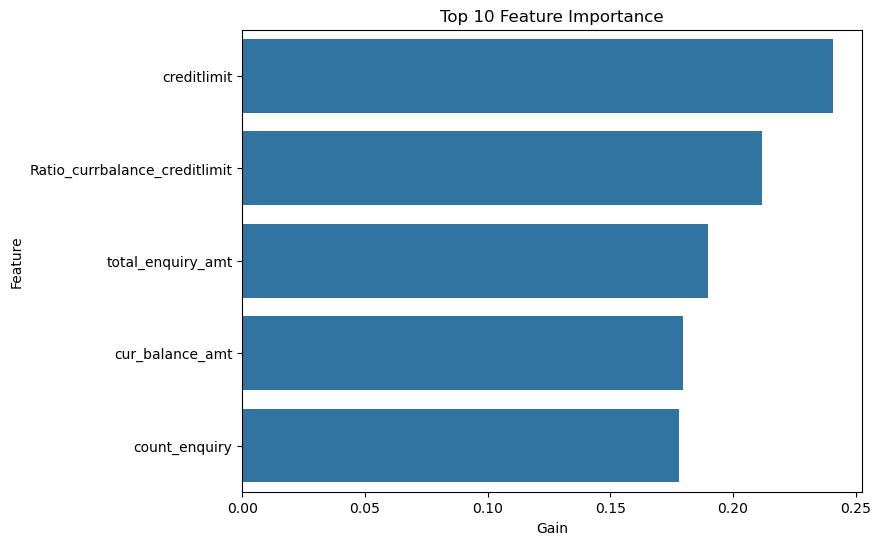

In [51]:
plt.figure(figsize=(8,6))
sns.barplot(x='Gain', y='Feature', data=importance.head(10))
plt.title("Top 10 Feature Importance")
plt.show()

# Conclusion

In this project, a credit risk prediction model was developed for Bank GoodCredit to identify customers with high default risk (Bad_label = 1).

Data from customer accounts, enquiries, and demographic features were combined to create meaningful aggregated features such as credit utilization ratio and enquiry frequency.

Key Steps Performed:
• Data cleaning and preprocessing  
• Feature engineering using account and enquiry data  
• Target variable transformation  
• Stratified train-test split  
• Model building using XGBoost  
• Performance evaluation using AUC, Gini, and Decile Rank Ordering  

The model performance was evaluated using Gini coefficient and compared against the benchmark Gini of 37.9.

The decile analysis shows effective rank ordering, where higher deciles contain a higher concentration of bad customers, demonstrating good model discriminatory power.

Important predictive features included:
• Ratio of current balance to credit limit  
• Enquiry count and enquiry amount  
• Aggregated account behaviour features  

Overall, the model successfully predicts customer credit risk and can help the bank reduce default losses by improving credit decision-making.